In [1]:
from numpy import pi, array, sort, multiply, sum
import numpy as np

In [2]:
# AU definition [m]
AU = 149597870700.
# Universal gravitational constant [m^3.kg^-1.s^-2]
G_universal = 6.67430e-11
# Universal gas constant [J.mol^-1.K^-1]
R = 8.31446261815324 
# Number of seconds in a day
day_s = 24.0*3600.0

# ===== SUN/EARTH PARAMETERS =====
M_Sun        = 1988400e24 # Solar mass [kg]
L_Sun        = 3.828e26   # Solar luminosity [W]
radius_Earth = 6.371e6    # Earth radius [m]
mass_Earth   = 5.9722e24  # Earth mass [kg]
grav_Earth   = 9.807      # Earth surface gravity [m.s^-2]

def angular_velocity(orbital_period):
	return 2.0*pi/(orbital_period*day_s)

def weighted_mean(mix_ratios,y):
	return sum(multiply(array(mix_ratios),array(y))) 

def surface_gravity(mass,radius):
	g = G_universal*array(mass)*mass_Earth/(array(radius)*radius_Earth)**2
	if g.ndim > 0:
		g = sort(g)
	return g

In [3]:
planets = { 'Earth': {'Stellar Luminosity': L_Sun, 'Radius': radius_Earth, 'Gravity': grav_Earth, 'Semi-major axis': AU, 'Angular velocity': angular_velocity(1.0)},
            'TRAPPIST-1b': {'Stellar Luminosity': 0.000553*L_Sun, 'Radius': 1.116*radius_Earth, 'Gravity': 1.102*grav_Earth, 'Semi-major axis': 0.01154*AU, 'Angular velocity': angular_velocity(1.510826)},
            'TRAPPIST-1c': {'Stellar Luminosity': 0.000553*L_Sun, 'Radius': 1.097*radius_Earth, 'Gravity': 1.086*grav_Earth, 'Semi-major axis': 0.01580*AU, 'Angular velocity': angular_velocity(2.421937)},
			'TRAPPIST-1d': {'Stellar Luminosity': 0.000553*L_Sun, 'Radius': 0.788*radius_Earth, 'Gravity': 0.624*grav_Earth, 'Semi-major axis': 0.02227*AU, 'Angular velocity': angular_velocity(4.049219)},
			'TRAPPIST-1e': {'Stellar Luminosity': 0.000553*L_Sun, 'Radius': 0.920*radius_Earth, 'Gravity': 0.817*grav_Earth, 'Semi-major axis': 0.02925*AU, 'Angular velocity': angular_velocity(6.101013)},
			'Proxima-b':   {'Stellar Luminosity': 0.001567*L_Sun, 'Radius': array([0.94,1.4])*radius_Earth, 'Gravity': surface_gravity(1.07,[0.94,1.4]), 'Semi-major axis': 0.04856*AU, 'Angular velocity': angular_velocity(11.1868)},
			'Teegarden-b':   {'Stellar Luminosity': 0.00073*L_Sun, 'Radius': 1.02*radius_Earth, 'Gravity': surface_gravity(1.16,1.02), 'Semi-major axis': 0.0259*AU, 'Angular velocity': angular_velocity(4.90634)},
			'Teegarden-c':   {'Stellar Luminosity': 0.00073*L_Sun, 'Radius': 1.04*radius_Earth, 'Gravity': surface_gravity(1.05,1.04), 'Semi-major axis': 0.0455*AU, 'Angular velocity': angular_velocity(11.416)},
			'Teegarden-d':   {'Stellar Luminosity': 0.00073*L_Sun, 'Radius': 1.04*radius_Earth, 'Gravity': surface_gravity(0.82,1.04), 'Semi-major axis': 0.0791*AU, 'Angular velocity': angular_velocity(26.13)},
			'HD137010b':     {'Stellar Luminosity': 0.232*L_Sun, 'Radius': 1.06*radius_Earth, 'Gravity': surface_gravity(1.2,1.06), 'Semi-major axis': 0.88*AU, 'Angular velocity': angular_velocity(1.0)}}


In [4]:
planet     = 'HD137010b'

In [5]:
solar_constant = (1.0 - 0.0) * planets[planet]['Stellar Luminosity']   / (4. * np.pi * (planets[planet]['Semi-major axis'])**2)

In [6]:
solar_constant

407.7874741409989

In [7]:
solar_constant_Earth = (1.0 - 0.0) * planets['Earth']['Stellar Luminosity']   / (4. * np.pi * (planets['Earth']['Semi-major axis'])**2)
solar_constant_Earth

1361.1664654085753

In [8]:
solar_constant/solar_constant_Earth

0.2995867768595042

In [9]:
R_Sun = 6.957e8  # Solar radius [m]
R_HD137010b = 0.707*R_Sun
R_HD137010b

491859900.0

In [10]:
from CoolProp.CoolProp import PropsSI

def p_sat_co2(T):
    """
    Returns the saturation vapor pressure of CO2 at temperature T [K].
    This works for temperatures from ~216.6 K (triple point) up to ~303 K (near critical).
    """
    # Q=1 gives saturated vapor pressure
    try:
        return PropsSI('P', 'T', T, 'Q', 1, 'CO2')
    except ValueError:
        # Outside the saturation range (below triple point or above critical)
        raise ValueError(f"T={T} K outside valid CO2 saturation range")

# Example: print the CO2 saturation pressure at 220 K
print(f"p_sat @220 K: {p_sat_co2(220):.1f} Pa")


p_sat @220 K: 599130.4 Pa


In [32]:
temperature = 273.15  # Example temperature in K
Total_pressure = 1e6  # Example total pressure in Pa
p_co2_partial = 0.7*Total_pressure  # Example partial pressure of CO2 in Pa
if p_co2_partial >= p_sat_co2(temperature):
    print("CO2 will condense at this temperature and pressure.")

In [33]:
p_sat_co2(temperature)

3485140.757663161

In [35]:
p_co2_partial

700000.0

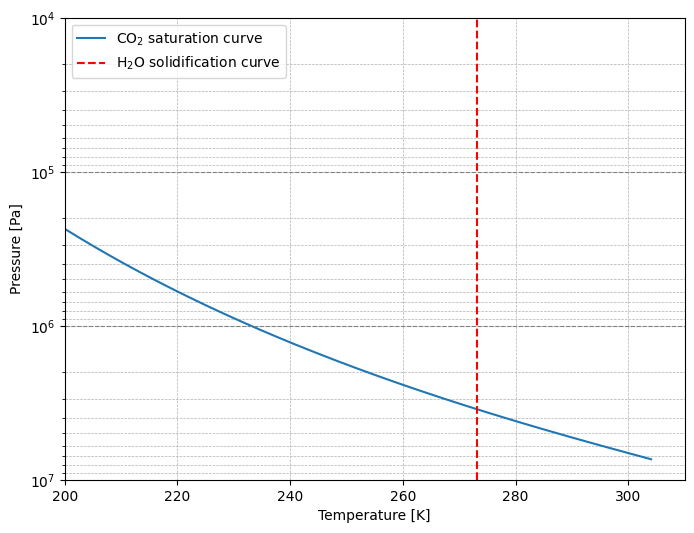

In [44]:
import matplotlib.pyplot as plt

# Temperature range
T_min = 200
T_max = 310
T = np.linspace(T_min, T_max, 500)

# Compute CO2 saturation curve
p_sat = []
for Ti in T:
    try:
        p = PropsSI('P', 'T', Ti, 'Q', 1, 'CO2')
    except ValueError:
        # Above critical temp (~304K): saturation undefined
        p = np.nan
    p_sat.append(p)
p_sat = np.array(p_sat)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(T, p_sat, label=r'CO$_2$ saturation curve')
ax.set_yscale('log')           # log scale for pressure
ax.invert_yaxis()              # invert y axis (high pressure at bottom) :contentReference[oaicite:1]{index=1}

# Optional: mark interesting pressure levels
for pl in [1e5, 1e6]:
    ax.axhline(pl, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlim(T_min, T_max)
ax.axvline(x=273.15, color='red', linestyle='--', linewidth=1.5, label=r'H$_2$O solidification curve')
ax.set_ylim(1e7, 1e4)          # Pa (top=low pressure, bottom=high)
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Pressure [Pa]')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend()
fig.savefig('/home/x_ryabo/Isca-Ryan/exp/HD137010b_7/'+'Co2_sat_curve.pdf',bbox_inches='tight')
fig.savefig('/home/x_ryabo/Isca-Ryan/exp/HD137010b_7/'+'Co2_sat_curve.png',bbox_inches='tight')
plt.show()


In [47]:
50000.0/1e5

0.5

In [53]:
5e5 * 1e-6

0.5

In [ ]:
#200 to 500 mbar of CO2 = 20000 to 50000 Pa
# In ppmv, 0.5 = 5e6
# 400 ppmv = 400 * 1e-6

temperature = 273.15  # Example temperature in K
Total_pressure = 1e5  # Example total pressure in Pa
p_co2_partial = 0.5*Total_pressure  # Example partial pressure of CO2 in Pa
if p_co2_partial >= p_sat_co2(temperature):
    print("CO2 will condense at this temperature and pressure.")